# 03b — Road Detector v0.10 (Random Forest)

Replaces the v0.9 rule-based ridge-filter + global-threshold pipeline with a supervised per-pixel classifier trained on `roads_truth.gpkg`. Method follows *Detecting abandoned roads beneath forest canopy with LiDAR and Python.md* § "Random Forest on terrain derivative stacks."

**Feature stack (12 layers, co-registered 1 m rasters):** slope, roughness_11, local_relief_10, tpi_05, tpi_15, tpi_51, tpi_grad_mag, lrm_25, lrm_51, openness_pos, openness_neg, intensity_ground.

**Training labels from `roads_truth.gpkg`:**
- **positives** = pixels within 2 m of any truth road centreline
- **negatives** = pixels > 15 m from any truth road (uniformly sampled)
- **excluded** = the 2–15 m grey zone (ambiguous)

Output overwrites `candidates_roads.gpkg` so `05_expert_validation.ipynb` scores the new result without any changes. The v0.9 output is archived under `data/derivatives/archive/v0.9_rule_based_pre_rf/`.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio import features
from scipy import ndimage as ndi
from shapely.geometry import LineString
from sklearn.ensemble import RandomForestClassifier
from skimage.morphology import skeletonize, remove_small_objects, binary_closing, disk
from skimage.measure import regionprops, label as sk_label
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from datetime import datetime
import time, uuid

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DERIV = PROJECT / 'data' / 'derivatives'
CAND  = DERIV / 'candidates'
ANNO  = DERIV / 'annotations'
LOGS  = PROJECT / 'docs'
CAND.mkdir(parents=True, exist_ok=True)

DETECTION_METHOD = 'road_v0.10_random_forest'
RUN_ID = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:6]
RNG = np.random.default_rng(42)
print('run_id:', RUN_ID)


run_id: 20260415T031830Z-e57988


C:\Users\colto\AppData\Local\Temp\ipykernel_49648\340142917.py:25: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_ID = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:6]


## 1. Load the 12-feature stack

In [2]:
FEATURES = [
    ('slope',            'slope.tif'),
    ('roughness_11',     'roughness_11.tif'),
    ('local_relief_10',  'local_relief_10.tif'),
    ('tpi_05',           'tpi_05.tif'),
    ('tpi_15',           'tpi_15.tif'),
    ('tpi_51',           'tpi_51.tif'),
    ('tpi_grad_mag',     'tpi_grad_mag.tif'),
    ('lrm_25',           'lrm_25.tif'),
    ('lrm_51',           'lrm_51.tif'),
    ('openness_pos',     'openness_pos.tif'),
    ('openness_neg',     'openness_neg.tif'),
    ('intensity_ground', 'intensity_ground.tif'),
]

def rd(fname):
    with rasterio.open(DERIV / fname) as ds:
        a = ds.read(1).astype(np.float32)
        nd = ds.nodata
        if nd is not None:
            a = np.where(a == nd, np.nan, a)
        return a, ds.transform, ds.crs

_, transform, crs = rd(FEATURES[0][1])
layers = {name: rd(f)[0] for name, f in FEATURES}
H, W = layers['slope'].shape
cs = float(transform.a)
X0, Y1 = transform.c, transform.f
X1 = X0 + W * cs; Y0 = Y1 - H * cs
print(f'grid {H}x{W} @ {cs} m, CRS {crs.to_string()[:50]}...')

X = np.stack([layers[n] for n, _ in FEATURES], axis=-1).astype(np.float32)
valid_pixel = np.all(np.isfinite(X), axis=-1)
print(f'valid (all 12 features finite): {valid_pixel.sum():,} / {H*W:,} ({100*valid_pixel.mean():.2f}%)')

for k, (name, _) in enumerate(FEATURES):
    band = X[:, :, k]
    if np.any(np.isnan(band)):
        med = float(np.nanmedian(band))
        band[np.isnan(band)] = med


grid 1500x1500 @ 1.0 m, CRS COMPD_CS["NAD83(2011) / UTM zone 17N + NAVD88 heig...
valid (all 12 features finite): 2,059,697 / 2,250,000 (91.54%)


## 2. Build training labels from `roads_truth.gpkg`

In [3]:
roads_t = gpd.read_file(ANNO / 'roads_truth.gpkg').to_crs(crs)
print(f'truth roads: {len(roads_t)}, total length {roads_t.length.sum():.0f} m')

POS_BUFFER_M = 2.0
NEG_EXCLUDE_M = 15.0

pos_shapes = [(geom, 1) for geom in roads_t.buffer(POS_BUFFER_M).geometry]
exclude_shapes = [(geom, 1) for geom in roads_t.buffer(NEG_EXCLUDE_M).geometry]

pos_mask = features.rasterize(pos_shapes, out_shape=(H, W), transform=transform, fill=0, dtype='uint8').astype(bool)
exclude_mask = features.rasterize(exclude_shapes, out_shape=(H, W), transform=transform, fill=0, dtype='uint8').astype(bool)
neg_mask = valid_pixel & (~exclude_mask)
pos_mask = valid_pixel & pos_mask

n_pos = int(pos_mask.sum())
n_neg_pool = int(neg_mask.sum())
print(f'positive pixels (buffered truth road, +/-{POS_BUFFER_M:.0f} m): {n_pos:,}')
print(f'negative pool (outside +/-{NEG_EXCLUDE_M:.0f} m): {n_neg_pool:,}')
print(f'grey-zone excluded: {int((exclude_mask & ~pos_mask).sum()):,}')


truth roads: 96, total length 19315 m
positive pixels (buffered truth road, +/-2 m): 71,914
negative pool (outside +/-15 m): 1,547,046
grey-zone excluded: 483,446


## 3. Sample + train the Random Forest

In [4]:
N_NEG = min(5 * n_pos, n_neg_pool)

pos_idx = np.flatnonzero(pos_mask.ravel())
neg_idx = np.flatnonzero(neg_mask.ravel())
neg_sample = RNG.choice(neg_idx, size=N_NEG, replace=False)
train_idx = np.concatenate([pos_idx, neg_sample])
y = np.concatenate([np.ones(n_pos, dtype=np.int8), np.zeros(N_NEG, dtype=np.int8)])
X_train = X.reshape(-1, X.shape[-1])[train_idx]
print(f'training set: {len(y):,} rows  (pos {n_pos:,} / neg {N_NEG:,})')

rf = RandomForestClassifier(
    n_estimators=500, max_depth=20, min_samples_leaf=10,
    class_weight='balanced', n_jobs=-1, oob_score=True, bootstrap=True, random_state=42,
)
t0 = time.time()
rf.fit(X_train, y)
print(f'trained in {time.time()-t0:.1f}s, OOB score: {rf.oob_score_:.4f}')

imp = pd.DataFrame({'feature': [n for n, _ in FEATURES], 'importance': rf.feature_importances_}) \
        .sort_values('importance', ascending=False).reset_index(drop=True)
print('feature importances:')
print(imp.to_string(index=False))


training set: 431,484 rows  (pos 71,914 / neg 359,570)


trained in 125.2s, OOB score: 0.9173
feature importances:
         feature  importance
    openness_pos    0.211860
          tpi_05    0.124338
          lrm_25    0.105950
    tpi_grad_mag    0.099920
          tpi_15    0.080741
    openness_neg    0.073266
           slope    0.067108
          lrm_51    0.059761
          tpi_51    0.055261
 local_relief_10    0.045401
    roughness_11    0.044085
intensity_ground    0.032309


## 4. Predict probability raster

In [5]:
t0 = time.time()
proba = rf.predict_proba(X.reshape(-1, X.shape[-1]))[:, 1].reshape(H, W).astype(np.float32)
proba[~valid_pixel] = 0.0
print(f'predicted in {time.time()-t0:.1f}s')
print(f'proba  p50={np.percentile(proba, 50):.3f}  p95={np.percentile(proba, 95):.3f}  max={proba.max():.3f}')

with rasterio.open(
    DERIV / 'rf_road_proba.tif', 'w',
    driver='GTiff', height=H, width=W, count=1, dtype='float32',
    crs=crs, transform=transform, nodata=-1.0, tiled=True, compress='deflate', predictor=3,
) as ds:
    out = np.where(valid_pixel, proba, -1.0).astype(np.float32)
    ds.write(out, 1)
print('wrote rf_road_proba.tif')


predicted in 13.2s
proba  p50=0.044  p95=0.828  max=0.995


wrote rf_road_proba.tif


## 5. Threshold -> morphology -> keep elongated

In [6]:
TH = {
    'proba_min':             0.50,
    'closing_radius_cells':  2,
    'min_component_area_m2': 120.0,
    'min_eccentricity':      0.82,
    'min_segment_length_m':  30.0,
    'positional_uncert_m':   100.0,
    'xsec_spacing_m':        5.0,
    'xsec_half_width_m':    15.0,
    'xsec_edge_min_width_m': 2.0,
    'xsec_edge_max_width_m':12.0,
}

bm = proba >= TH['proba_min']
bm = binary_closing(bm, footprint=disk(TH['closing_radius_cells']))
bm = remove_small_objects(bm, min_size=int(TH['min_component_area_m2'] / (cs * cs)))
print(f'pixels above proba>={TH["proba_min"]}: {100*bm.mean():.2f}% of tile')

labels = sk_label(bm)
props = regionprops(labels)
keep_labels = {p.label for p in props
               if p.eccentricity >= TH['min_eccentricity']
               and p.area * cs * cs >= TH['min_component_area_m2']}
elongated = np.isin(labels, list(keep_labels))
print(f'elongated components: {len(keep_labels)} / {len(props)}')


pixels above proba>=0.5: 12.91% of tile
elongated components: 122 / 143


## 6. Skeletonize -> vectorize

In [7]:
skel = skeletonize(elongated)
skel_labels, n_skel = ndi.label(skel, structure=np.ones((3, 3), dtype=bool))
print(f'skeleton components: {n_skel}')

def trace_component(coords):
    if len(coords) == 1: return coords
    cs_set = set(map(tuple, coords))
    def bfs_far(seed):
        seen = {seed: None}; front = [seed]; last = seed
        while front:
            nxt = []
            for p in front:
                for dy in (-1,0,1):
                    for dx in (-1,0,1):
                        if not dy and not dx: continue
                        q = (p[0]+dy, p[1]+dx)
                        if q in cs_set and q not in seen:
                            seen[q] = p; nxt.append(q); last = q
            front = nxt
        return last, seen
    a, _ = bfs_far(tuple(coords[0]))
    b, parent = bfs_far(a)
    path = []
    cur = b
    while cur is not None:
        path.append(cur); cur = parent[cur]
    path.reverse()
    return np.array(path)

segments = []; seg_len_m = []; mean_proba = []
for lab in range(1, n_skel + 1):
    where = np.argwhere(skel_labels == lab)
    if len(where) < 3: continue
    path_px = trace_component(where)
    xs = X0 + (path_px[:, 1] + 0.5) * cs
    ys = Y1 - (path_px[:, 0] + 0.5) * cs
    line = LineString(list(zip(xs, ys)))
    if line.length < TH['min_segment_length_m']: continue
    segments.append(line); seg_len_m.append(line.length)
    mean_proba.append(float(np.mean(proba[path_px[:, 0], path_px[:, 1]])))
print(f'kept {len(segments)} segments (>= {TH["min_segment_length_m"]:.0f} m)')

roads = gpd.GeoDataFrame({
    'cand_id': range(1, len(segments)+1),
    'length_m': seg_len_m,
    'mean_proba': mean_proba,
    'geometry': segments,
}, crs=crs)


skeleton components: 122


kept 101 segments (>= 30 m)


## 6b. Cross-section attribution + nearest-well

In [8]:
with rasterio.open(DERIV / 'dem_1m.tif') as ds:
    dem = ds.read(1).astype(np.float32); nd = ds.nodata
if nd is not None:
    dem = np.where(dem == nd, np.nan, dem)

def sample_dem(xs, ys):
    c = (xs - X0) / cs - 0.5
    r = (Y1 - ys) / cs - 0.5
    c0 = np.floor(c).astype(np.int64); c1 = c0 + 1
    r0 = np.floor(r).astype(np.int64); r1 = r0 + 1
    fc = (c - c0).astype(np.float32); fr = (r - r0).astype(np.float32)
    c0 = np.clip(c0, 0, W-1); c1 = np.clip(c1, 0, W-1)
    r0 = np.clip(r0, 0, H-1); r1 = np.clip(r1, 0, H-1)
    z00 = dem[r0, c0]; z01 = dem[r0, c1]; z10 = dem[r1, c0]; z11 = dem[r1, c1]
    return ((1-fr)*((1-fc)*z00 + fc*z01) + fr*((1-fc)*z10 + fc*z11)).astype(np.float32)

def seg_attrs(line):
    total = line.length
    if total < TH['xsec_spacing_m'] * 2:
        return np.nan, np.nan, np.nan, np.nan, 0
    n_x = int(total / TH['xsec_spacing_m']) + 1
    widths, depths = [], []
    half = TH['xsec_half_width_m']
    d_arr = np.linspace(-half, half, int(2*half)+1).astype(np.float32)
    for i in range(n_x):
        s = min(i * TH['xsec_spacing_m'], total)
        pt = line.interpolate(s)
        pa = line.interpolate(min(s + 0.5, total))
        pb = line.interpolate(max(s - 0.5, 0))
        tx = pa.x - pb.x; ty = pa.y - pb.y
        tl = np.hypot(tx, ty) or 1.0
        tx /= tl; ty /= tl; nx, ny = -ty, tx
        xs_ = pt.x + d_arr * nx; ys_ = pt.y + d_arr * ny
        z = sample_dem(xs_, ys_)
        if not np.all(np.isfinite(z)): continue
        trend = np.polyfit(d_arr, z, 1)
        z_det = z - (trend[0] * d_arr + trend[1])
        gmag = np.abs(np.gradient(z_det))
        centre = len(z_det) // 2
        lg, rg = gmag[:centre], gmag[centre+1:]
        if lg.size == 0 or rg.size == 0: continue
        lp, _ = find_peaks(lg, height=np.percentile(lg, 70))
        rp, _ = find_peaks(rg, height=np.percentile(rg, 70))
        if len(lp) == 0 or len(rp) == 0: continue
        le, re = lp[-1], centre + 1 + rp[0]
        w = float(d_arr[re] - d_arr[le])
        if w < TH['xsec_edge_min_width_m'] or w > TH['xsec_edge_max_width_m']: continue
        depth = float(max(z_det[le], z_det[re]) - z_det[centre])
        widths.append(w); depths.append(max(depth, 0.0))
    if not widths:
        return np.nan, np.nan, np.nan, np.nan, 0
    return (float(np.median(widths)), float(np.percentile(widths, 90)),
            float(np.median(depths)), float(np.percentile(depths, 90)), int(len(widths)))

attrs = [seg_attrs(g) for g in roads.geometry]
roads['median_width_m']     = [a[0] for a in attrs]
roads['p90_width_m']        = [a[1] for a in attrs]
roads['median_cut_depth_m'] = [a[2] for a in attrs]
roads['p90_cut_depth_m']    = [a[3] for a in attrs]
roads['n_xsec_valid']       = [a[4] for a in attrs]

wells = gpd.read_file(DERIV / 'wells_in_tile.gpkg').to_crs(crs)
nw_d, nw_id = [], []
for line in roads.geometry:
    ds_ = line.distance(wells.geometry)
    i = ds_.idxmin()
    nw_d.append(float(ds_.iloc[i])); nw_id.append(wells.iloc[i].Well_ident)
roads['nearest_well_m'] = nw_d
roads['nearest_well_id'] = nw_id
roads['inside_positional_uncertainty'] = roads['nearest_well_m'] <= TH['positional_uncert_m']

len_score   = np.clip(roads['length_m'] / 200.0, 0, 1)
depth_score = np.clip(roads['median_cut_depth_m'].fillna(0.0) / 0.5, 0, 1)
prob_score  = np.clip(roads['mean_proba'], 0, 1)
roads['confidence_score'] = (0.45*prob_score + 0.35*len_score + 0.20*depth_score).astype(np.float32)
roads['confidence_label'] = np.where(roads['confidence_score'] > 0.70, 'probable', 'candidate')
roads['detection_method'] = DETECTION_METHOD
roads['run_id'] = RUN_ID

print(f'median length: {roads.length_m.median():.1f} m, p95: {roads.length_m.quantile(.95):.1f} m')
print(f'median nearest-well: {roads.nearest_well_m.median():.1f} m')
print(roads.confidence_label.value_counts().to_string())


median length: 48.5 m, p95: 225.1 m
median nearest-well: 52.3 m
confidence_label
candidate    86
probable     15


## 7. Export

In [9]:
export = roads.sort_values('confidence_score', ascending=False).reset_index(drop=True)
export['cand_id'] = np.arange(1, len(export)+1, dtype=np.int64)

COLS = ['cand_id', 'detection_method', 'run_id', 'confidence_score', 'confidence_label',
        'length_m', 'mean_proba',
        'median_width_m', 'p90_width_m', 'median_cut_depth_m', 'p90_cut_depth_m', 'n_xsec_valid',
        'nearest_well_m', 'nearest_well_id', 'inside_positional_uncertainty', 'geometry']
export = export[COLS]

GPKG = CAND / 'candidates_roads.gpkg'
PARQ = CAND / 'candidates_roads.parquet'
GPKG.unlink(missing_ok=True)
export.to_file(GPKG, layer='candidates_roads', driver='GPKG')
export.drop(columns='geometry').to_parquet(PARQ, index=False)
print(f'wrote {GPKG.name} ({len(export)} rows)')


wrote candidates_roads.gpkg (101 rows)


## 8. QA plots

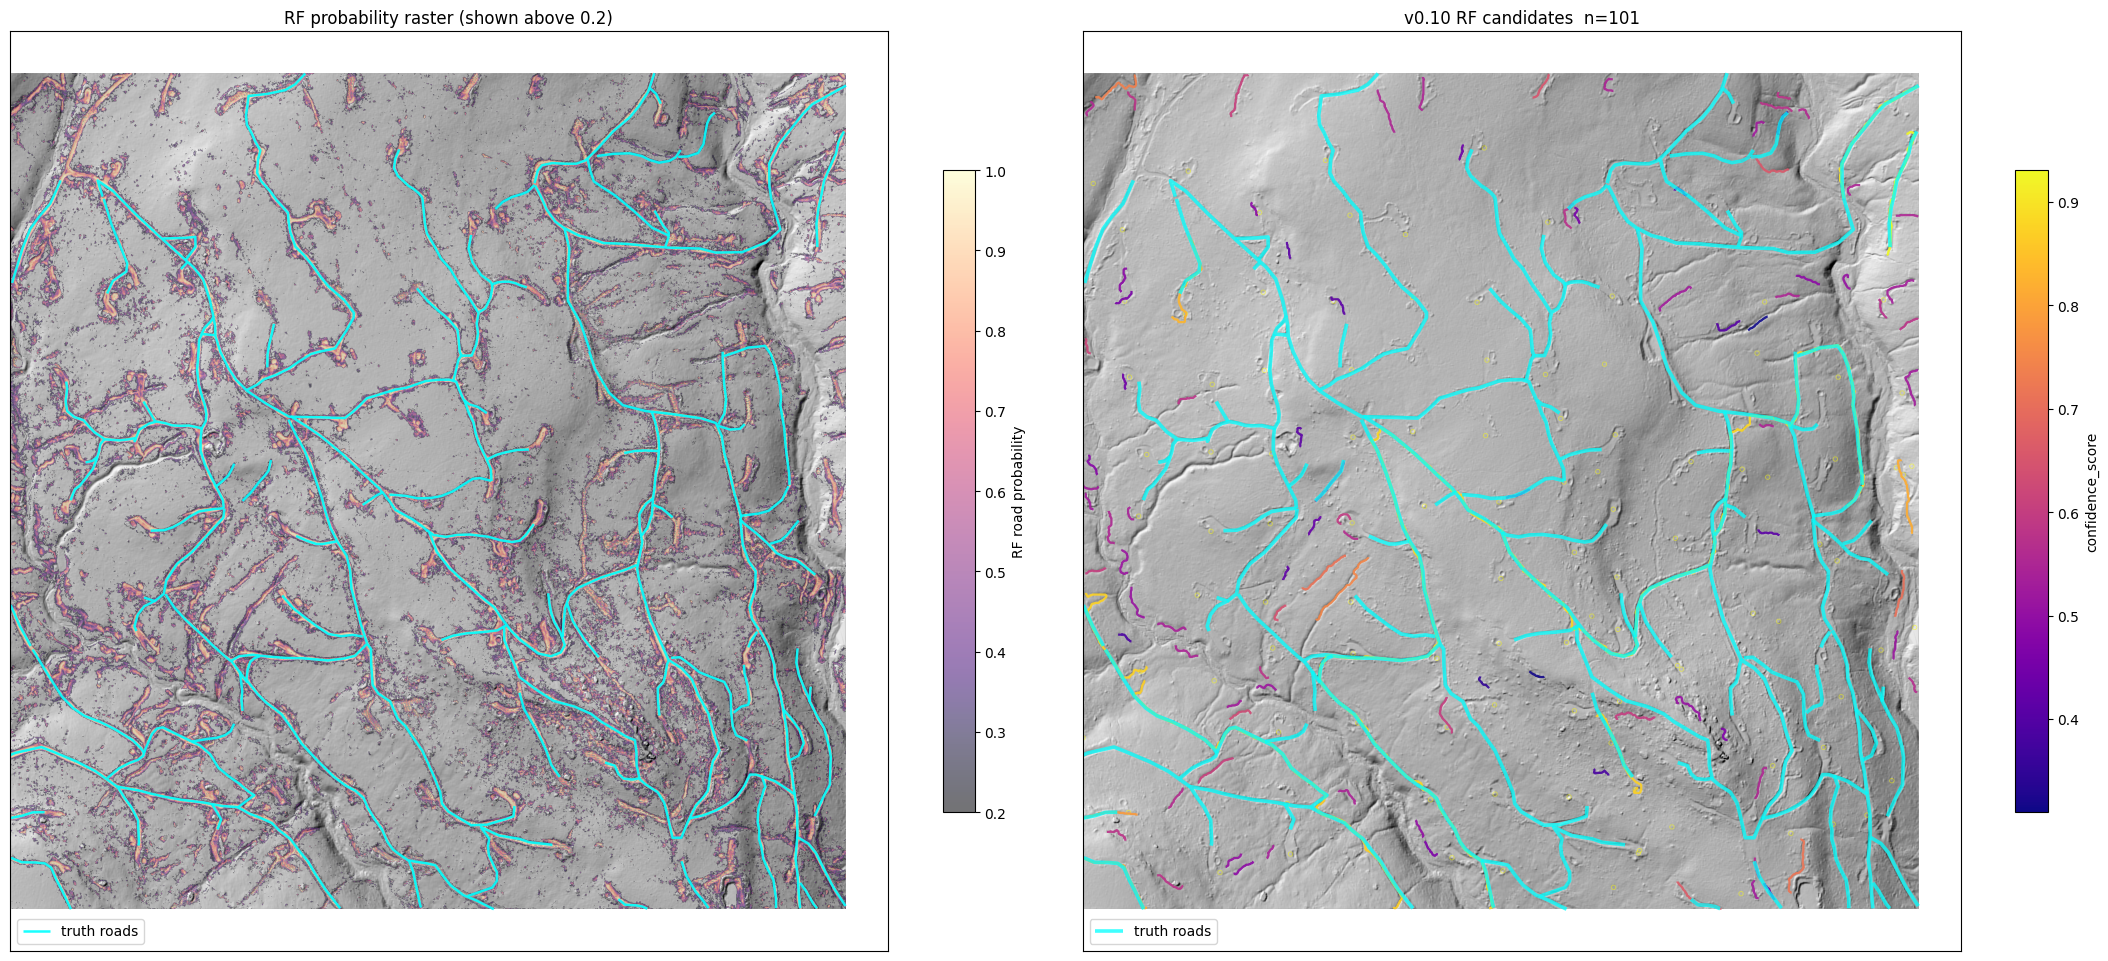

In [10]:
with rasterio.open(DERIV / 'hillshade.tif') as ds:
    hs = ds.read(1)
ext = (X0, X1, Y0, Y1)

fig, axes = plt.subplots(1, 2, figsize=(22, 11))

ax = axes[0]
ax.imshow(hs, cmap='gray', extent=ext, origin='upper')
pr = np.where(proba > 0.2, proba, np.nan)
im = ax.imshow(pr, cmap='magma', extent=ext, origin='upper', alpha=0.55, vmin=0.2, vmax=1.0)
roads_t.plot(ax=ax, color='cyan', linewidth=1.8, label='truth roads', alpha=0.9)
plt.colorbar(im, ax=ax, shrink=0.6, label='RF road probability')
ax.set_title('RF probability raster (shown above 0.2)'); ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='lower left')

ax = axes[1]
ax.imshow(hs, cmap='gray', extent=ext, origin='upper')
export.plot(ax=ax, column='confidence_score', cmap='plasma', linewidth=1.6, alpha=0.9, legend=True,
            legend_kwds={'label':'confidence_score','shrink':0.6})
roads_t.plot(ax=ax, color='cyan', linewidth=2.6, alpha=0.75, label='truth roads')
ax.scatter(wells.geometry.x, wells.geometry.y, s=10, facecolor='none', edgecolor='yellow', linewidths=0.6, alpha=0.5)
ax.set_title(f'v0.10 RF candidates  n={len(export)}'); ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='lower left')
plt.tight_layout(); plt.savefig(DERIV / 'v10_rf_overview.png', dpi=130, bbox_inches='tight')
plt.show()


## 9. Append log entry

In [11]:
entry = (
    f'\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} - Road detector v0.10 (Random Forest)  run {RUN_ID}\n\n'
    f'- Training: {n_pos:,} pos / {N_NEG:,} neg pixels, 12 features, OOB score {rf.oob_score_:.4f}\n'
    f'- Top-3 features: ' + ', '.join(f"{r.feature} ({r.importance:.3f})" for r in imp.head(3).itertuples()) + '\n'
    f'- Proba threshold {TH["proba_min"]}  ->  {len(export)} final LineStrings\n'
    f'- Confidence: {int((export.confidence_label=="probable").sum())} probable, {int((export.confidence_label=="candidate").sum())} candidate\n'
    f'- Median segment length {export.length_m.median():.0f} m, median cut depth {export.median_cut_depth_m.median():.2f} m\n'
    f'- Output: candidates_roads.gpkg (v0.9 archived under archive/v0.9_rule_based_pre_rf/)\n'
    f'- Run 05_expert_validation.ipynb next to rescore.\n'
)
with open(LOGS / 'analysis_log.md', 'a', encoding='utf-8') as f:
    f.write(entry)
print(entry)



## 2026-04-15 03:20 UTC - Road detector v0.10 (Random Forest)  run 20260415T031830Z-e57988

- Training: 71,914 pos / 359,570 neg pixels, 12 features, OOB score 0.9173
- Top-3 features: openness_pos (0.212), tpi_05 (0.124), lrm_25 (0.106)
- Proba threshold 0.5  ->  101 final LineStrings
- Confidence: 15 probable, 86 candidate
- Median segment length 48 m, median cut depth 0.37 m
- Output: candidates_roads.gpkg (v0.9 archived under archive/v0.9_rule_based_pre_rf/)
- Run 05_expert_validation.ipynb next to rescore.



C:\Users\colto\AppData\Local\Temp\ipykernel_49648\3106357912.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f'\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} - Road detector v0.10 (Random Forest)  run {RUN_ID}\n\n'
